# Generate Data: Era 0

## Credit
Dataset was originally generated (i.e. spliced and pre-processed) by this notebook https://github.com/orcasound/aifororcas-livesystem/blob/4eaf038404b56ef087a6efaaf670b83206f30ec1/ModelTraining/1_DataCreation.ipynb.

## Table of Contents
1. Summary
2. Pre-Requisite Knowledge
3. Setup [Installing Dependencies, Importing Libraries, and Notebook Parameters]
4. Retrieve and Organize Dataset

## Summary:
We utilized the PodCast tool to generate a dataset of annotated .wav clips of both SRKW calls (positive) and noise (negative) with which to train a SRKW call detection model. This notebook downloads a dataset of pre-generated, spliced clips from PodCast annotated data (from AWS S3 storage bucket) and arranges them into orca-ml/data/[train|val|test]/ for our training and evaluation.

## Pre-Requisite Knowledge:
* We have two sources of annotated data for SRKW call detection learning. (1) The PodCast-labeled data processed with this notebook. (2) The OrcaHello-labeled data process with 1b_GenerateDataEra1.
* We refer to PodCast-labeled data as Era0 dataset; no one has generated new data with this tool since ~2019. 
* We refer to OrcaHello-labeled data from 2020-2024 as Era1 dataset; everything here is either true- or false-positive detected by our original production SRKW call detection model and manually-labeled by our team of moderators.

## Installing Dependencies

In [1]:
import sys
!{sys.executable} -m pip install -r ../requirements.txt

  Cloning https://github.com/kevinbird15/fastaudio.git (to revision fastaudio_refresh) to /tmp/pip-req-build-vwpbogsh
  Running command git clone --filter=blob:none --quiet https://github.com/kevinbird15/fastaudio.git /tmp/pip-req-build-vwpbogsh
  Running command git checkout -b fastaudio_refresh --track origin/fastaudio_refresh
  Switched to a new branch 'fastaudio_refresh'
  branch 'fastaudio_refresh' set up to track 'origin/fastaudio_refresh'.
  Resolved https://github.com/kevinbird15/fastaudio.git to commit 045a276d227387c630b6aa1a3eba6fae1f6646c4
  Preparing metadata (setup.py) ... done


## Importing libraries

In [2]:
from datetime import date
from pathlib import Path
import random
from tqdm.notebook import tqdm_notebook

# Standard lib packages
from collections import Counter
import math
from pathlib import Path
import random
import shutil

# 3rd party packages
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchaudio
from tqdm.autonotebook import tqdm

/tmp/ipykernel_15008/874776677.py:18: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Notebook Parameters

In [3]:
# Absolute path to the orca-ml repo
REPO_ROOT = Path.cwd().parent

# Absolute path to directory where we'll copy in subset of processed data for training
ERA0_DATA_FOLDER = REPO_ROOT / 'data' / 'era0'

ERA0_RAW_TRAIN_DATA_FOLDER = ERA0_DATA_FOLDER / 'raw-train' / 'mldata' / 'all'
ERA0_RAW_TEST_DATA_FOLDER = ERA0_DATA_FOLDER / 'raw-test' / 'all'

# Random seed for result reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Train-validation split proportion of minority class training data
# Raw training data will be split as follows:
# # Train set will contain following proportion of minority class and equal number of majority class examples
# # Validation set will contain the rest of the raw training data
# Note: test set is ~12% of total Era 0 dataset and kept separate
TRAIN_SET_MINORITY_CLASS_PROPORTION = 0.8

# Maximum length of any audio example in dataset; any example longer than this value will be ignored
MAX_EXAMPLE_LENGTH_SECONDS = 4

In [4]:
def extract_metadata(items: list[Path]):
    """Extract audio metadata from each file."""
    metadata = dict()
    for item in tqdm_notebook(items):
        torchaudio_metadata = torchaudio.info(item)
        metadata[item] = {
            'sample_rate':torchaudio_metadata.sample_rate,
            'num_channels':torchaudio_metadata.num_channels,
            'duration':(torchaudio_metadata.num_frames/torchaudio_metadata.sample_rate)
        }

    print(metadata.values())
    
    sample_rates = Counter(x['sample_rate'] for x in metadata.values())
    num_channels = Counter(x['num_channels'] for x in metadata.values())
    print("Sample Rates:")
    for rate, count in sample_rates.items():
        print(f"- {rate} Hz: {count} files")
    print("Sample Rates:")
    for channels, count in num_channels.items():
        print(f"- {channels} Channels: {count} files")

    return metadata

def get_clip_duration_seconds(clip_filepath: Path):
    torchaudio_metadata = torchaudio.info(clip_filepath)
    return (torchaudio_metadata.num_frames/torchaudio_metadata.sample_rate)

# TODO: Clean out audio files with only one channel (or just simplify all to single channel)

## Unzip Era0 Dataset

In [ ]:
# TODO Put quickstart_data.tar.gz into AWS S3 bucket for easy download

# TODO Script up download quickstart_data.tar.gz to local machine

# TODO Unzip quickstart data into orca-ml/data/era0 folder

## Split Era0 Train Set into Train & Validation

In [ ]:
# Create train and validation set folders if they don't yet exist
era0_trn_data_folder = ERA0_DATA_FOLDER / 'train'
era0_val_data_folder = ERA0_DATA_FOLDER / 'val'
(era0_trn_data_folder / 'positive').mkdir(parents=True, exist_ok=True)
(era0_trn_data_folder / 'negative').mkdir(parents=True, exist_ok=True)
(era0_val_data_folder / 'positive').mkdir(parents=True, exist_ok=True)
(era0_val_data_folder / 'negative').mkdir(parents=True, exist_ok=True)

if not ERA0_DATA_FOLDER.exists():
    raise Exception(f'Era 0 raw training set not found; unzip era0dataset.zip to {ERA0_DATA_FOLDER.parent}')

# Load applicable positive and negative clip filepaths into memory
era0_pos_raw_trn_all_clips = list((ERA0_RAW_TRAIN_DATA_FOLDER / 'positive').rglob("*.wav"))
era0_neg_raw_trn_all_clips = list((ERA0_RAW_TRAIN_DATA_FOLDER / 'negative').rglob("*.wav"))
if len(era0_pos_raw_trn_all_clips) < 1 or len(era0_neg_raw_trn_all_clips) < 1:
    raise Exception(f'Era 0 raw training set not found; unzip era0dataset.zip to {ERA0_DATA_FOLDER.parent}')
era0_pos_raw_trn_clips = [x for x in era0_pos_raw_trn_all_clips if get_clip_duration_seconds(x) <= MAX_EXAMPLE_LENGTH_SECONDS]
era0_neg_raw_trn_clips = [x for x in era0_neg_raw_trn_all_clips if get_clip_duration_seconds(x) <= MAX_EXAMPLE_LENGTH_SECONDS]

# Balance distribution of clips between positive and negative via random selection (without replacement)
random.shuffle(era0_pos_raw_trn_clips)
random.shuffle(era0_neg_raw_trn_clips)
trn_val_split_index = int(TRAIN_SET_MINORITY_CLASS_PROPORTION * min(len(era0_pos_raw_trn_clips), len(era0_neg_raw_trn_clips)))
era0_pos_trn_clips = era0_pos_raw_trn_clips[:trn_val_split_index]
era0_pos_val_clips = era0_pos_raw_trn_clips[trn_val_split_index:]
era0_neg_trn_clips = era0_neg_raw_trn_clips[:trn_val_split_index]
era0_neg_val_clips = era0_neg_raw_trn_clips[trn_val_split_index:]

# Copy files into era0 train and validation folders
for file in era0_pos_trn_clips: shutil.copy(file, era0_trn_data_folder / 'positive' / file.name)
for file in era0_pos_val_clips: shutil.copy(file, era0_val_data_folder / 'positive' / file.name)
for file in era0_neg_trn_clips: shutil.copy(file, era0_trn_data_folder / 'negative' / file.name)
for file in era0_neg_val_clips: shutil.copy(file, era0_val_data_folder / 'negative' / file.name)

pos_trn_metadata = extract_metadata(list((era0_trn_data_folder / 'positive').rglob("*.wav")))
neg_trn_metadata = extract_metadata(list((era0_trn_data_folder / 'negative').rglob("*.wav")))
pos_val_metadata = extract_metadata(list((era0_val_data_folder / 'positive').rglob("*.wav")))
neg_val_metadata = extract_metadata(list((era0_val_data_folder / 'negative').rglob("*.wav")))


  0%|          | 0/2353 [00:00<?, ?it/s]

dict_values([{'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 4.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 4.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num

  0%|          | 0/2353 [00:00<?, ?it/s]

dict_values([{'sample_rate': 20000, 'num_channels': 1, 'duration': 3.154}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.97185}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.6761}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.5034}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.46085}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.39595}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.33705}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.9297}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.8374}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.5781}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.5873}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.36135}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.8409}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.3508}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.48575}, {'sample_rate': 20000, 'num_channels'

  0%|          | 0/589 [00:00<?, ?it/s]

dict_values([{'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 4.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 4.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 4.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 4.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 4.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.25}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'nu

  0%|          | 0/1689 [00:00<?, ?it/s]

dict_values([{'sample_rate': 20000, 'num_channels': 1, 'duration': 3.1133}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.503}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.73085}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.5201}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.7702}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.2799}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.366}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.09975}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.28345}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.356}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.01165}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.20415}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.2124}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0175}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.5204}, {'sample_rate': 20000, 'num_channels': 1

### Show Distribution of Clip Duration over Train and Validation Sets

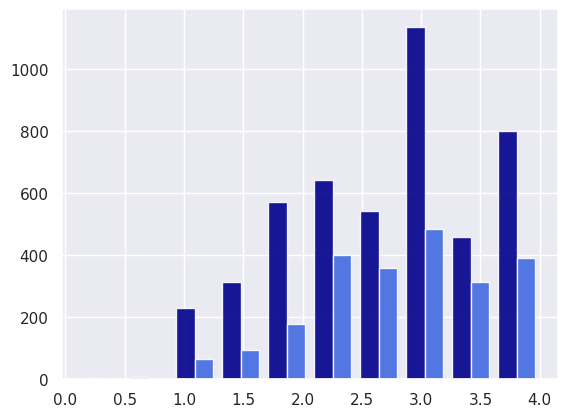

In [18]:
trn_durations = [x['duration'] for x in pos_trn_metadata.values()] + [x['duration'] for x in neg_trn_metadata.values()]
val_durations = [x['duration'] for x in pos_val_metadata.values()] + [x['duration'] for x in neg_val_metadata.values()]

sns.set_theme()
plot = plt.hist(
    [trn_durations, val_durations],
    color=['darkblue','royalblue'],
    alpha=0.9
)

### Show Distribution of Clip Duration over {Train and Validation, Positive and Negative} Sets

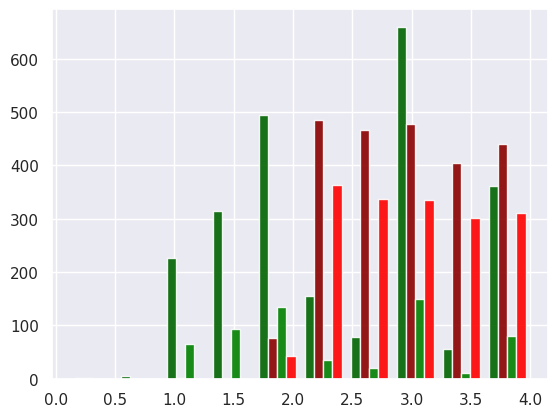

In [26]:
pos_trn_durations = [x['duration'] for x in pos_trn_metadata.values()]
neg_trn_durations = [x['duration'] for x in neg_trn_metadata.values()]
pos_val_durations = [x['duration'] for x in pos_val_metadata.values()]
neg_val_durations = [x['duration'] for x in neg_val_metadata.values()]

sns.set_theme()
plot = plt.hist(
    [pos_trn_durations, neg_trn_durations, pos_val_durations, neg_val_durations],
    color=['darkgreen','darkred', 'green', 'red'],
    alpha=0.9
)

## Filter Out Non-Applicable Test Data

In [27]:
# Create test set folder if it doesn't yet exist
era0_tst_data_folder = ERA0_DATA_FOLDER / 'test'
(era0_tst_data_folder / 'positive').mkdir(parents=True, exist_ok=True)
(era0_tst_data_folder / 'negative').mkdir(parents=True, exist_ok=True)

if not ERA0_DATA_FOLDER.exists():
    raise Exception(f'Era 0 raw test set not found; unzip era0dataset.zip to {ERA0_DATA_FOLDER.parent}')

# Load applicable positive and negative clip filepaths into memory
era0_pos_raw_tst_all_clips = list((ERA0_RAW_TEST_DATA_FOLDER / 'positive').rglob("*.wav"))
era0_neg_raw_tst_all_clips = list((ERA0_RAW_TEST_DATA_FOLDER / 'negative').rglob("*.wav"))
if len(era0_pos_raw_tst_all_clips) < 1 or len(era0_neg_raw_tst_all_clips) < 1:
    raise Exception(f'Era 0 raw test set not found; unzip era0dataset.zip to {ERA0_DATA_FOLDER.parent}')
era0_pos_raw_tst_clips = [x for x in era0_pos_raw_tst_all_clips if get_clip_duration_seconds(x) <= MAX_EXAMPLE_LENGTH_SECONDS]
era0_neg_raw_tst_clips = [x for x in era0_neg_raw_tst_all_clips if get_clip_duration_seconds(x) <= MAX_EXAMPLE_LENGTH_SECONDS]

# Copy files into era0 train and validation folders
for file in era0_pos_raw_tst_clips: shutil.copy(file, era0_tst_data_folder / 'positive' / file.name)
for file in era0_neg_raw_tst_clips: shutil.copy(file, era0_tst_data_folder / 'negative' / file.name)

pos_tst_metadata = extract_metadata(list((era0_tst_data_folder / 'positive').rglob("*.wav")))
neg_tst_metadata = extract_metadata(list((era0_tst_data_folder / 'negative').rglob("*.wav")))

  0%|          | 0/478 [00:00<?, ?it/s]

dict_values([{'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.0}, {'sample_rate': 20000, 'num

  0%|          | 0/535 [00:00<?, ?it/s]

dict_values([{'sample_rate': 20000, 'num_channels': 1, 'duration': 3.1637}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.37555}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.39115}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.01375}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.21845}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.86095}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.19855}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.5668}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.9928}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.4281}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.57035}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.09805}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 3.30665}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.37925}, {'sample_rate': 20000, 'num_channels': 1, 'duration': 2.2165}, {'sample_rate': 20000, 'num_chan

### Show Distribution of Clip Duration over Positive and Negative Test Data

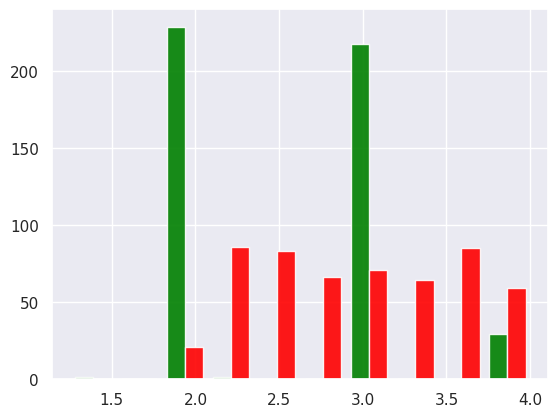

In [28]:
pos_durations = [x['duration'] for x in pos_tst_metadata.values()]
neg_durations = [x['duration'] for x in neg_tst_metadata.values()]

sns.set_theme()
plot = plt.hist(
    [pos_durations, neg_durations],
    color=['green','red'],
    alpha=0.9
)